# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [ ]:
ПІБ = 'Бісюк Роман Васильович'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-34'      # напр. 'КН-31'
ВАРІАНТ = 1    # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [ ]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Бісюк Роман Васильович, ШІ-34, варіант 1
ваш потік:                   P>50
ваша пара для графіка 3:     швидкість вітру та потік P>10
ваш агрегат для етапу 4:     медіана
ваше додаткове питання:      Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [ ]:
# ВАШ КОД
df = pd.read_excel(ФАЙЛ)
display(df.head())
print(df.dtypes)

,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN


Unnamed: 0                                     float64
ftp://ftp.swpc.noaa.gov/pub/lists/particle/     object
Unnamed: 2                                      object
Unnamed: 3                                      object
Unnamed: 4                                      object
Unnamed: 5                                      object
Unnamed: 6                                      object
Unnamed: 7                                      object
Unnamed: 8                                      object
Unnamed: 9                                      object
Unnamed: 10                                     object
Unnamed: 11                                     object
Unnamed: 12                                     object
Unnamed: 13                                     object
Unnamed: 14                                     object
Unnamed: 15                                    float64
Unnamed: 16                                     object
Unnamed: 17                                     object
Unnamed: 1

**Відповідь 1.1:**

 Pandas взяв перший рядок аркуша за заголовки стовпців, хоча там насправді метадані — джерело даних, дата збору, посилання на опис величин на кшталт "швидкість/густина протонів". Через це стовпці отримали дивні назви (сам цей текст або Unnamed: 0, Unnamed: 1...), а типи даних поплуталися: там, де мали бути числа, тепер стоїть object (текст), бо в стовпці впереміш і цифри, і службові написи. Також видно, що на аркуші не одна таблиця, а декілька — окремо про частинки (GOES) і окремо про сонячний вітер (SOHO), просто розташовані поруч по стовпцях, і звичайне читання злило їх в одну беззмістовну таблицю.

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [ ]:
RAW = pd.read_excel(ФАЙЛ, header=None)
print(RAW.shape)
RAW.head(30)


(7226, 32)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [ ]:
# ВАШ КОД
RAW.notna().sum()

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64

**Відповідь 1.3:** *(скільки таблиць і які стовпці кожна займає)*

Існує 3 таблиці:

1 таблиця займає стовпці 1-14

2 таблиця займає стовпці 16-19

3 таблиця займає стовпці 24-31

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [ ]:
pd.set_option('display.max_colwidth', None)

print("ТАБЛИЦЯ A (стовпець 1, ftp NOAA/GOES)")
print(RAW.iloc[:13, 1].to_string())

print("\n ТАБЛИЦЯ B (стовпці 16-19, ftp NOAA/F10.7)")
print(RAW.iloc[:16, 16:20].to_string())

print("\n ТАБЛИЦЯ C (стовпці 24-31, SOHO)")
print(RAW.iloc[:8, 24:32].to_string())

ТАБЛИЦЯ A (стовпець 1, ftp NOAA/GOES)
0                                         ftp://ftp.swpc.noaa.gov/pub/lists/particle/
1                                                                                 NaN
2                                                 :Data_list: 20170901_Gs_part_5m.txt
3                                                      :Created: 2017 Sep 02 0011 UTC
4     # Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center
5                  # Please send comments and suggestions to SWPC.Webmaster@noaa.gov 
6                                                                                  # 
7                                                # Label: P > 1 = Particles at >1 Mev
8                                                # Label: P > 5 = Particles at >5 Mev
9                                               # Label: P >10 = Particles at >10 Mev
10                                              # Label: P >30 = Particles at >30 Mev
11              

**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | NOAA SWPC, супутник GOES-15, файл `20170901_Gs_part_5m.txt` (потоки частинок) | потоки частинок різної енергії (P>1, P>5, P>10 Mev тощо) — у частинках/см²·с·стерадіан |
| B | NOAA SWPC, файл `2017Q3_DSD.txt` (добові сонячні індекси, F10.7) | сонячний радіопотік F10.7, у сонячних потокових одиницях (sfu) |
| C | SOHO CELIAS Proton Monitor (`http://umtof.umd.edu/pm/crn/`) | швидкість протонів — км/с (km/sec); густина протонів — частинок/см³ (protons per cubic centimeter) |

---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [ ]:
A = RAW.iloc[:, 1:15].apply(pd.to_numeric, errors='coerce')
A.columns = ['рік','місяць','день','час_ггхх','julian_day','сек',
'P>1','P>5','P>10','P>30','P>50','P>100','E>0.8','E>2.0']
A = A.dropna(subset=['рік','місяць','день']).reset_index(drop=True)

B = RAW.iloc[:, 16:20].apply(pd.to_numeric, errors='coerce')
B.columns = ['рік','місяць','день','F10.7']
B = B.dropna().reset_index(drop=True)

C = RAW.iloc[:, 26:32].apply(pd.to_numeric, errors='coerce')
C.columns = ['рік','місяць','день','година','швидкість вітру','густина вітру']
C = C.dropna(subset=['рік','місяць','день']).reset_index(drop=True)

print(A.shape, B.shape, C.shape)

(7200, 14) (25, 4) (601, 6)


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [ ]:
A['година'] = (A['час_ггхх'] // 100).astype(int)
A['хвилина'] = (A['час_ггхх'] % 100).astype(int)
A['ts'] = pd.to_datetime(dict(
    year=A['рік'].astype(int), month=A['місяць'].astype(int), day=A['день'].astype(int),
    hour=A['година'], minute=A['хвилина']
))

B['ts'] = pd.to_datetime(dict(
    year=B['рік'].astype(int), month=B['місяць'].astype(int), day=B['день'].astype(int)
))

C['рік'] = C['рік'].apply(lambda y: y + 2000 if y < 100 else y)
C['ts'] = pd.to_datetime(dict(
    year=C['рік'].astype(int), month=C['місяць'].astype(int), day=C['день'].astype(int),
    hour=C['година'].astype(int)
))

print('A:', A['ts'].min(), '—', A['ts'].max())
print('B:', B['ts'].min(), '—', B['ts'].max())
print('C:', C['ts'].min(), '—', C['ts'].max())

A: 2017-08-28 00:00:00 — 2017-09-21 23:55:00
B: 2017-08-28 00:00:00 — 2017-09-21 00:00:00
C: 2017-08-28 00:00:00 — 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [ ]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [ ]:
for name, df in [('Таблиця A', A), ('Таблиця B', B), ('Таблиця C', C)]:
    print(f"=== {name} ===")
    print(f"Розмір (рядків, стовпців): {df.shape}")
    print(f"Кількість дублікатів: {df.duplicated().sum()}")
    print("\nТипи та пропуски:")
    info_df = pd.DataFrame({
        'Тип': df.dtypes,
        'Пропуски': df.isna().sum()
    })
    display(info_df)
    
    print("\nОписові статистики:")
    display(df.describe())
    print("=" * 60 + "\n")

=== Таблиця A ===
Розмір (рядків, стовпців): (7200, 17)
Кількість дублікатів: 0

Типи та пропуски:


,Тип,Пропуски
рік,float64,0
місяць,float64,0
день,float64,0
час_ггхх,float64,0
julian_day,float64,0
сек,float64,0
P>1,float64,3
P>5,float64,3
P>10,float64,3
P>30,float64,3



Описові статистики:


,рік,місяць,день,час_ггхх,julian_day,сек,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,година,хвилина,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200.000000,7200.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,11.500000,27.500000,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,0.000000,0.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,5.750000,13.750000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,11.500000,27.500000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,17.250000,41.250000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,23.000000,55.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,6.922667,17.261461,NaN



=== Таблиця B ===
Розмір (рядків, стовпців): (25, 5)
Кількість дублікатів: 0

Типи та пропуски:


...

,рік,місяць,день,F10.7,ts
count,25.0,25.000000,25.000000,25.000000,25
mean,2017.0,8.840000,13.960000,92.680000,2017-09-09 00:00:00
min,2017.0,8.000000,1.000000,71.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,74.000000,2017-09-03 00:00:00
50%,2017.0,9.000000,13.000000,84.000000,2017-09-09 00:00:00
75%,2017.0,9.000000,19.000000,107.000000,2017-09-15 00:00:00
max,2017.0,9.000000,31.000000,140.000000,2017-09-21 00:00:00
std,0.0,0.374166,8.955817,22.206831,NaN



=== Таблиця C ===
Розмір (рядків, стовпців): (601, 7)
Кількість дублікатів: 0

Типи та пропуски:


,Тип,Пропуски
рік,float64,0
місяць,float64,0
день,float64,0
година,float64,0
швидкість вітру,float64,0
густина вітру,float64,0
ts,datetime64[us],0



Описові статистики:


,рік,місяць,день,година,швидкість вітру,густина вітру,ts
count,601.0,601.000000,601.000000,601.000000,601.000000,601.000000,601
mean,2017.0,8.840266,13.973378,11.480865,506.547421,2.907654,2017-09-09 12:00:00
min,2017.0,8.000000,1.000000,0.000000,-1.000000,-1.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,5.000000,447.000000,1.800000,2017-09-03 06:00:00
50%,2017.0,9.000000,13.000000,11.000000,517.000000,2.400000,2017-09-09 12:00:00
75%,2017.0,9.000000,19.000000,17.000000,584.000000,3.400000,2017-09-15 18:00:00
max,2017.0,9.000000,31.000000,23.000000,806.000000,31.700000,2017-09-22 00:00:00
std,0.0,0.366664,8.781000,6.938063,125.073291,2.637873,NaN


### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [ ]:
print("--- ДО ОЧИЩЕННЯ (Таблиця C) ---")
display(C[['швидкість вітру', 'густина вітру']].describe().loc[['min', 'mean']])

# Рахуємо кількість від'ємних значень
neg_speed = (C['швидкість вітру'] < 0).sum()
neg_density = (C['густина вітру'] < 0).sum()
print(f"\nКількість від'ємних значень:")
print(f"  - швидкість вітру: {neg_speed}")
print(f"  - густина вітру: {neg_density}")

# Замінюємо від'ємні значення на NaN
C.loc[C['швидкість вітру'] < 0, 'швидкість вітру'] = np.nan
C.loc[C['густина вітру'] < 0, 'густина вітру'] = np.nan

print("\n--- ПІСЛЯ ОЧИЩЕННЯ (Таблиця C) ---")
display(C[['швидкість вітру', 'густина вітру']].describe().loc[['min', 'mean']])

--- ДО ОЧИЩЕННЯ (Таблиця C) ---


,швидкість вітру,густина вітру
min,-1.000000,-1.000000
mean,506.547421,2.907654



Кількість від'ємних значень:
  - швидкість вітру: 8
  - густина вітру: 8

--- ПІСЛЯ ОЧИЩЕННЯ (Таблиця C) ---


,швидкість вітру,густина вітру
min,277.000000,0.100000
mean,513.394604,2.960371


**Відповідь 3.2:** 
Це технічні маркери збою датчиків (замість пропусків записали -999.0). Вони ламали весь аналіз: робили мінімум від'ємним, а середнє тягнули сильно вниз (густина взагалі виходила від'ємною). Коли прибрали їх у NaN, середнє стало адекватним і показало реальний стан вітру.

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [ ]:
# ВАШ КОД
# Виводимо описові статистики саме для стовпців часу та дати
часові_стовпці = ['рік', 'місяць', 'день', 'час_ггхх', 'julian_day', 'сек']
A[часові_стовпці].describe()

,рік,місяць,день,час_ггхх,julian_day,сек
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000


**Відповідь 3.3:** 
Це стовпці часу й дати: рік, місяць, день, час_ггхх, julian_day, сек.

Вони є числовими мітками «коли виміряно», а не фізичними величинами. Середній рік (2017) чи день нічого не означають, а для час_ггхх середнє взагалі математично хибне, бо запис не десятковий (після 1259 іде 1300).

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [ ]:
# ВАШ КОД
# Зводимо таблицю A до погодинної сітки (рахуємо mean та max для всіх потоків)
A_hourly = A.set_index('ts').resample('h').agg({
    'P>1': ['mean', 'max'],
    'P>5': ['mean', 'max'],
    'P>10': ['mean', 'max'],
    'P>30': ['mean', 'max'],
    'P>50': ['mean', 'max'],
    'P>100': ['mean', 'max'],
    'E>0.8': ['mean', 'max'],
    'E>2.0': ['mean', 'max']
})

print("Розмір погодинної таблиці A:", A_hourly.shape)
display(A_hourly.head())

Розмір погодинної таблиці A: (600, 16)


P>1              P>5             P>10             P>30              P>50             P>100                 E>0.8                 E>2.0        
                         mean    max      mean    max      mean    max      mean     max      mean     max      mean     max          mean      max         mean     max
ts                                                                                                                                                                      
2017-08-28 00:00:00  9.778333  19.40  0.324917  0.690  0.192917  0.314  0.098850  0.2240  0.077583  0.1780  0.040692  0.0793  20941.666667  23600.0  1011.583333  1180.0
2017-08-28 01:00:00  7.994167  13.60  0.291667  0.512  0.156583  0.259  0.072583  0.0919  0.058700  0.0798  0.029950  0.0471  18091.666667  20600.0   713.000000   907.0
2017-08-28 02:00:00  6.099167  10.80  0.283000  0.479  0.177667  0.321  0.084450  0.1210  0.069642  0.1110  0.035025  0.0595  14108.333333  15000.0   380.833333   475.0
2017-08-28 03:00:00  4.752500   7.76  0.236833  0.329  0.166333  0.244  0.087658  0.1800  0.068092  0.1390  0.035517  0.0818  12766.666667  13100.0   267.916667   284.0
2017-08-28 04:00:00  4.158333   6.62  0.334917  0.539  0.208333  0.309  0.084800  0.1530  0.072850  0.1420  0.039708  0.0694  11333.333333  12300.0   203.000000   234.0

### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одно
му графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

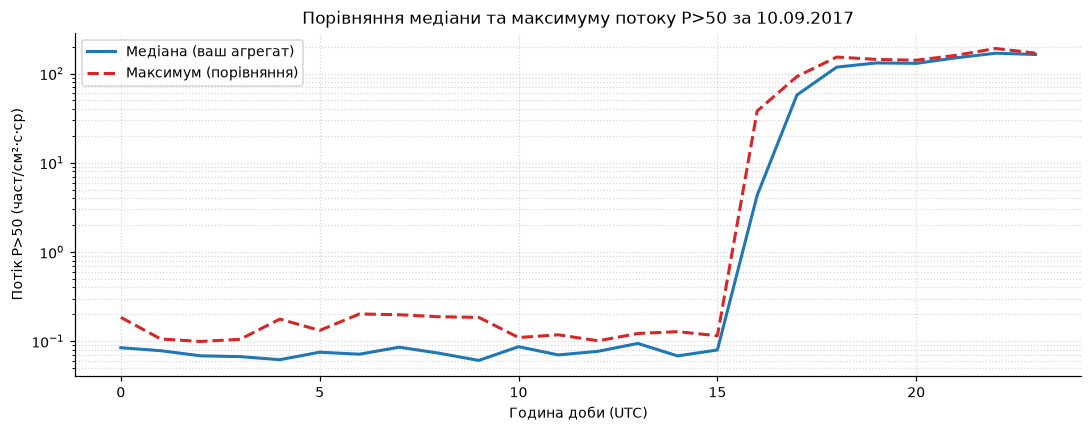

In [ ]:
# ВАШ КОД
# 1. Фільтруємо одну активну добу (10 вересня 2017 року)
доба = A[(A['ts'] >= '2017-09-10') & (A['ts'] < '2017-09-11')].copy()

# 2. Рахуємо твій агрегат (медіана) та другий для порівняння (максимум) по годинах
hourly_stats = доба.groupby(доба['ts'].dt.hour)['P>50'].agg(['median', 'max'])

# 3. Будуємо графік
plt.figure(figsize=(10, 4))
plt.plot(hourly_stats.index, hourly_stats['median'], label='Медіана (ваш агрегат)', color='#1f77b4', lw=2)
plt.plot(hourly_stats.index, hourly_stats['max'], label='Максимум (порівняння)', color='#d62728', lw=2, linestyle='--')

plt.title('Порівняння медіани та максимуму потоку P>50 за 10.09.2017')
plt.xlabel('Година доби (UTC)')
plt.ylabel('Потік P>50 (част/см²·с·ср)')
plt.yscale('log')  # логарифмічний масштаб краще показує різницю
plt.grid(True, which='both', ls=':', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

**Відповідь 4.2:** *(чим відрізняються криві та коли це важливо)*

Крива максимуму проходить вище за медіану, фіксуючи пікові імпульсні сплески в межах кожної години, тоді як медіана показує типовий фоновий рівень і згладжує короткочасні викиди.

Різниця між ними стає критично відчутною під час різких переходів або коротких сонячних спалахів (тривалістю кілька хвилин): один потужний 5-хвилинний імпульс злетить на графіку максимуму в рази або порядки, але практично не вплине на годинну медіану.

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [ ]:
# Перевіряємо, чи стовпці ще дворівневі (MultiIndex)
if isinstance(A_hourly.columns, pd.MultiIndex):
    A_hourly.columns = [f"{col}_{stat}" for col, stat in A_hourly.columns]

# Повертаємо 'ts' зі стовпця індексу, якщо він ще там
if 'ts' not in A_hourly.columns:
    A_hourly = A_hourly.reset_index()

# Готуємо дату для з'єднання з B
A_hourly['дата'] = A_hourly['ts'].dt.date
B['дата'] = B['ts'].dt.date

# 1. outer
M_outer = A_hourly.merge(C[['ts', 'швидкість вітру', 'густина вітру']], on='ts', how='outer')
M_outer = M_outer.merge(B[['дата', 'F10.7']], on='дата', how='outer').drop(columns=['дата'])

# 2. inner
M_inner = A_hourly.merge(C[['ts', 'швидкість вітру', 'густина вітру']], on='ts', how='inner')
M_inner = M_inner.merge(B[['дата', 'F10.7']], on='дата', how='inner').drop(columns=['дата'])

# Прибираємо тимчасові колонки
A_hourly.drop(columns=['дата'], inplace=True)
B.drop(columns=['дата'], inplace=True)

print(f"Розмір outer: {M_outer.shape}")
print(f"Розмір inner: {M_inner.shape}")

# Фіксуємо фінальну таблицю M
M = M_inner.copy()
print(f"Фінальний розмір M: {M.shape}")

# Знаходимо рядки з пропусками
пропуски = M[M.isna().any(axis=1)]
print(f"Рядків із пропусками: {len(пропуски)}")
display(пропуски)

Розмір outer: (601, 20)
Розмір inner: (600, 20)
Фінальний розмір M: (600, 20)
Рядків із пропусками: 8


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max,швидкість вітру,густина вітру,F10.7
175,2017-09-04 07:00:00,6.465833,10.10,0.262083,0.593,0.171500,0.294,0.085483,0.145,0.068558,0.134,0.031717,0.0523,90600.000000,100000.0,7410.833333,8950.0,NaN,NaN,140.0
176,2017-09-04 08:00:00,4.010833,5.08,0.256000,0.432,0.195833,0.336,0.086625,0.145,0.070033,0.134,0.036492,0.0546,73483.333333,79300.0,5048.333333,5850.0,NaN,NaN,140.0
177,2017-09-04 09:00:00,3.268333,4.42,0.303417,0.518,0.220333,0.302,0.105925,0.162,0.081975,0.134,0.046483,0.0765,60475.000000,68500.0,3715.833333,4480.0,NaN,NaN,140.0
178,2017-09-04 10:00:00,3.179167,4.74,0.252167,0.372,0.181833,0.280,0.101900,0.150,0.081675,0.120,0.054125,0.0894,64383.333333,68400.0,4122.500000,4710.0,NaN,NaN,140.0
179,2017-09-04 11:00:00,5.274167,7.98,0.295083,0.657,0.186917,0.276,0.089525,0.166,0.063983,0.110,0.033633,0.0684,79933.333333,88200.0,6345.833333,7430.0,NaN,NaN,140.0
180,2017-09-04 12:00:00,2.965000,4.85,0.217750,0.428,0.153500,0.239,0.089217,0.179,0.071217,0.144,0.037233,0.0679,80516.666667,88700.0,6080.000000,7420.0,NaN,NaN,140.0
181,2017-09-04 13:00:00,3.061667,3.86,0.275833,0.551,0.192833,0.329,0.104542,0.170,0.083783,0.159,0.041342,0.0611,76733.333333,85900.0,6015.833333,7540.0,NaN,NaN,140.0
182,2017-09-04 14:00:00,7.279167,10.80,0.231333,0.409,0.170583,0.313,0.086508,0.178,0.070667,0.166,0.037375,0.0888,83025.000000,90200.0,8552.500000,10500.0,NaN,NaN,140.0


**Відповідь 4.3:** *(який тип об'єднання обрано, скільки рядків дає кожен і чому)*

how='outer' дає 601 рядок, а how='inner' — 600. Один зайвий рядок у outer — це кінцева точка з таблиці C, якої немає в інших. Обрано inner, щоб залишити тільки синхронні години без штучних порожніх хвостів. 8 рядків із пропусками — це технічні збої сенсорів SOHO, де хибні мінусові значення замінено на NaN.

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [ ]:
def classify_group(val):
    if pd.isna(val):
        return np.nan
    elif val < 10:
        return 'тиха'
    elif val < 1000:
        return 'активна'
    else:
        return 'дуже активна'

max_p10_col = [col for col in M.columns if 'P>10' in str(col) and 'max' in str(col)][0]

M['група'] = M[max_p10_col].apply(classify_group)

print("Кількість годин у кожній групі:")
print(M['група'].value_counts())

Кількість годин у кожній групі:
група
тиха            411
активна         171
дуже активна     18
Name: count, dtype: int64


**Самоперевірка етапу 4.**

In [ ]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 600 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

Середнє: 7.4439 pfu
Медіана: 0.0802 pfu


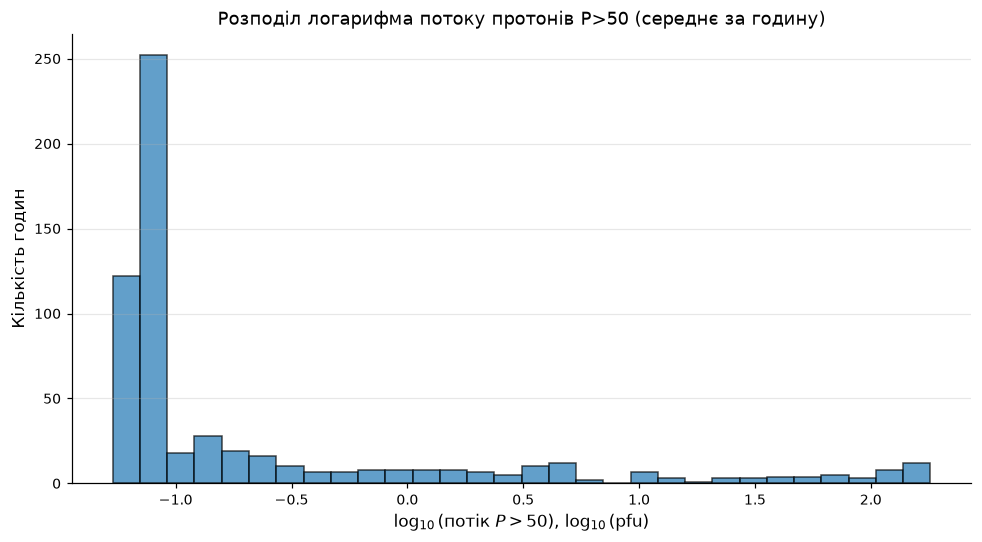

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Стовпець варіанта: потік P>50 (середнє за годину)
col = 'P>50_mean'

# Розрахунок середнього й медіани згідно з умовою
mean_val = M[col].mean()
median_val = M[col].median()

print(f"Середнє: {mean_val:.4f} pfu")
print(f"Медіана: {median_val:.4f} pfu")

# Гістограма від логарифма значень
data = M[col].dropna()
log_data = np.log10(data[data > 0])

plt.figure(figsize=(9, 5))
plt.hist(log_data, bins=30, edgecolor='black', alpha=0.7)

plt.title('Розподіл логарифма потоку протонів P>50 (середнє за годину)', fontsize=12)
plt.xlabel(r'$\log_{10}(\text{потік } P>50)$, $\log_{10}(\mathrm{pfu})$', fontsize=11)
plt.ylabel('Кількість годин', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Висновок:** 

Понад дві третини часу потік перебуває на мінімальному фоновому рівні біля 0.08 pfu, проте поодинокі спалахи сягають значень у сотні разів більших, через що середнє значення виявляється майже у сто разів вищим за медіану.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

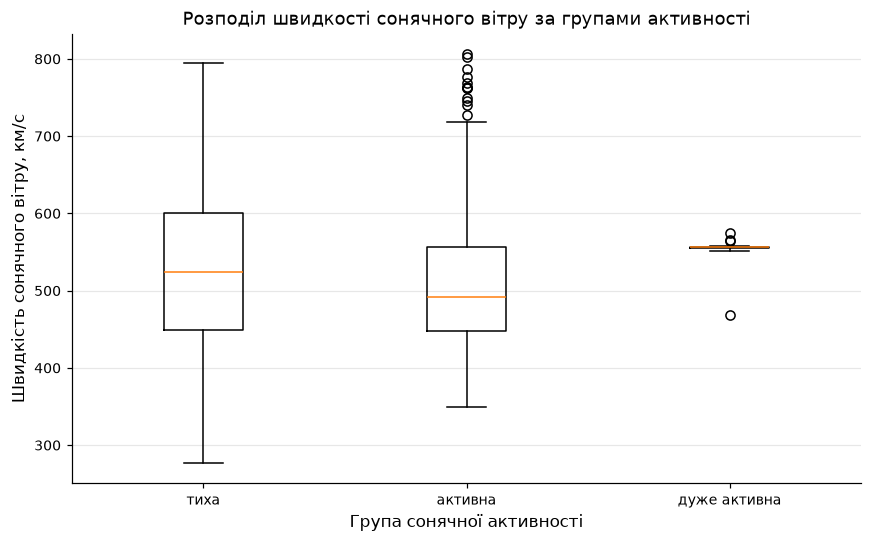

In [ ]:
# ВАШ КОД
import matplotlib.pyplot as plt

# Підготовка списку даних швидкості вітру для кожної групи без пропусків
groups = ['тиха', 'активна', 'дуже активна']
data_to_plot = [
    M[M['група'] == g]['швидкість вітру'].dropna() 
    for g in groups
]

plt.figure(figsize=(8, 5))
plt.boxplot(data_to_plot, tick_labels=groups)

plt.title('Розподіл швидкості сонячного вітру за групами активності', fontsize=12)
plt.xlabel('Група сонячної активності', fontsize=11)
plt.ylabel('Швидкість сонячного вітру, км/с', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Висновок:**

Медіанна швидкість вітру майже однакова для всіх груп (~500–550 км/с), проте в «активній» групі з'являється багато високих викидів до 800 км/с, а в «дуже активній» розкид значень є найвужчим.   

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

Коефіцієнт лінійної кореляції Пірсона: 0.0710


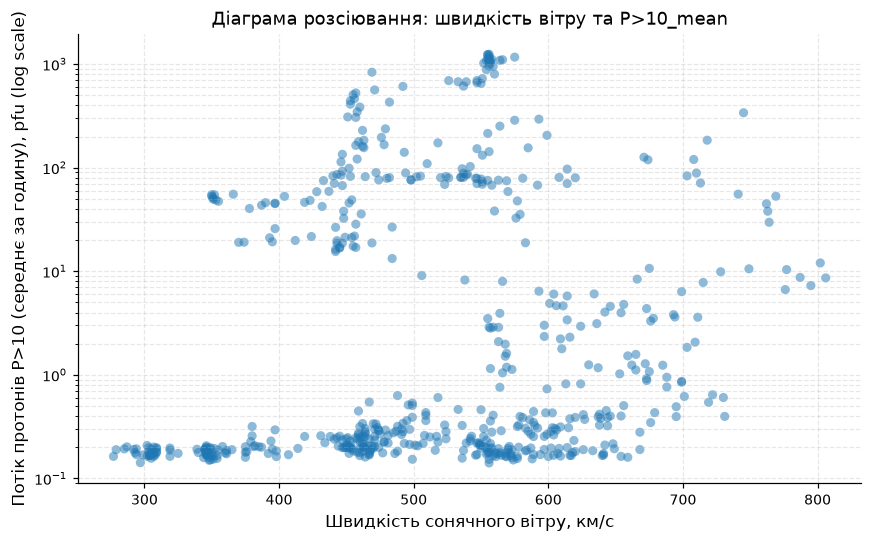

In [ ]:
# ВАШ КОД
import matplotlib.pyplot as plt
import numpy as np

# Вибираємо пару змінних та очищуємо від пропусків
x_col = 'швидкість вітру'
y_col = 'P>10_mean'

df_pair = M[[x_col, y_col]].dropna()
# Для кореляції та лог-масштабу залишаємо лише додатні значення
df_pair = df_pair[df_pair[y_col] > 0]

# Розрахунок кореляції Пірсона
corr = df_pair[x_col].corr(df_pair[y_col])
print(f"Коефіцієнт лінійної кореляції Пірсона: {corr:.4f}")

# Побудова діаграми розсіювання
plt.figure(figsize=(8, 5))
plt.scatter(df_pair[x_col], df_pair[y_col], alpha=0.5, edgecolors='none', color='tab:blue')

plt.yscale('log')
plt.title(f'Діаграма розсіювання: {x_col} та {y_col}', fontsize=12)
plt.xlabel('Швидкість сонячного вітру, км/с', fontsize=11)
plt.ylabel('Потік протонів P>10 (середнє за годину), pfu (log scale)', fontsize=11)
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Висновок:**

Між швидкістю сонячного вітру та потоком протонів немає вираженого лінійного зв'язку, оскільки точки розсіяні широкою хмарою, а екстремальні потоки понад $10^2\text{–}10^3\text{ pfu}$ спостерігаються як за помірної швидкості (~500–600 км/с), так і за високо

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

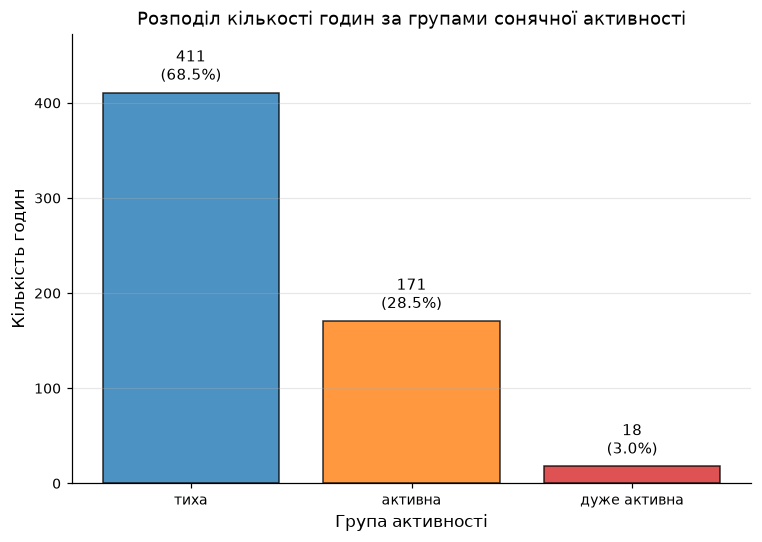

In [ ]:
# ВАШ КОД
import matplotlib.pyplot as plt

# Підрахунок кількості годин у кожній групі в логічному порядку
order = ['тиха', 'активна', 'дуже активна']
counts = M['група'].value_counts().reindex(order)
total = len(M)

plt.figure(figsize=(7, 5))
bars = plt.bar(counts.index, counts.values, color=['tab:blue', 'tab:orange', 'tab:red'], edgecolor='black', alpha=0.8)

# Додавання підписів кількості та відсотка над кожним стовпчиком
for bar in bars:
    height = bar.get_height()
    pct = (height / total) * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        height + 8, 
        f'{int(height)}\n({pct:.1f}%)', 
        ha='center', 
        va='bottom', 
        fontsize=10
    )

plt.title('Розподіл кількості годин за групами сонячної активності', fontsize=12)
plt.xlabel('Група активності', fontsize=11)
plt.ylabel('Кількість годин', fontsize=11)
plt.ylim(0, counts.max() * 1.15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Висновок:**

Переважну більшість часу Сонце перебуває у тихому стані (68.5%), на помірну активність припадає 28.5%, а екстремальні події трапляються вкрай рідко й охоплюють лише 3.0% усього періоду спостережень.   

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

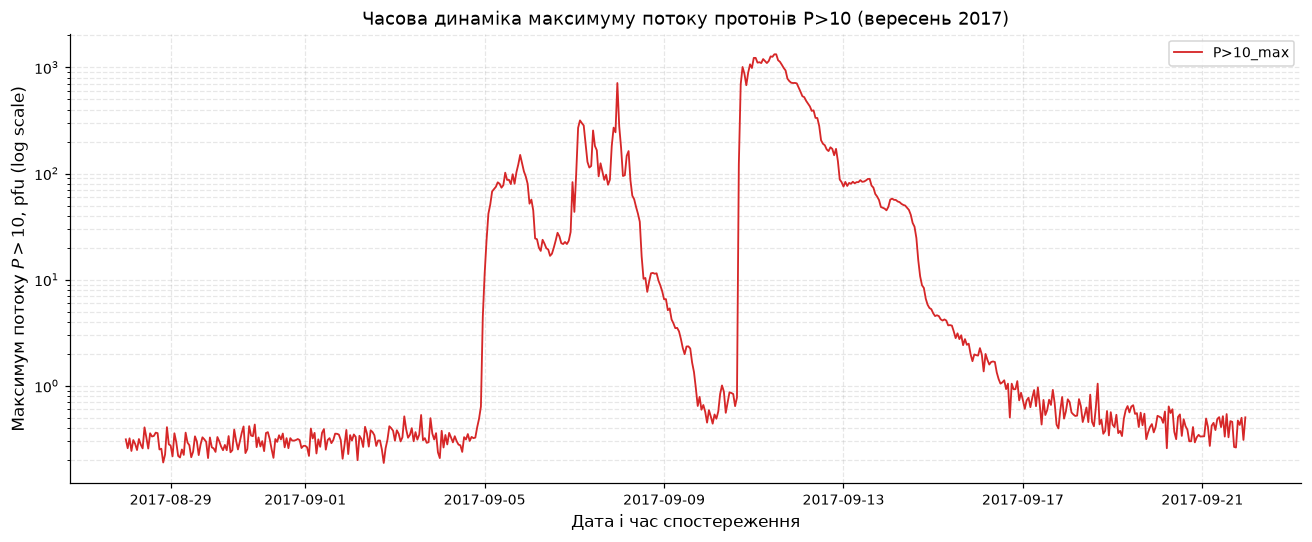

In [ ]:
# ВАШ КОД
import matplotlib.pyplot as plt

# Часовий ряд максимуму потоку P>10
# Переводимо у log10-масштаб через вісь Y (як у Графіку 1)
plt.figure(figsize=(12, 5))
plt.plot(M['ts'], M['P>10_max'], color='tab:red', linewidth=1.2, label='P>10_max')

plt.yscale('log')
plt.title('Часова динаміка максимуму потоку протонів P>10 (вересень 2017)', fontsize=12)
plt.xlabel('Дата і час спостереження', fontsize=11)
plt.ylabel(r'Максимум потоку $P>10$, pfu (log scale)', fontsize=11)
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Висновок:**

Протягом більшої частини періоду потік перебував на спокійному фоні нижче 1 pfu, однак 5 та 10 вересня відбулися два різкі спалахи з піковим зростанням активності більш ніж у тисячу разів.   

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

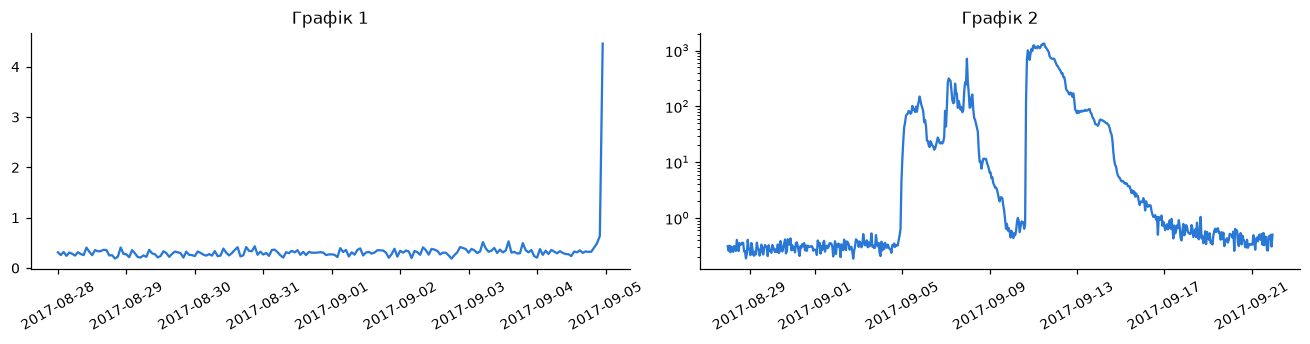

In [ ]:
СТОВПЕЦЬ = 'P>10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка:

Космічна погода була спокійною і стабільною без значущих аномалій майже весь час, окрім незначного підйому наприкінці періоду.   

2. Висновок з другого графіка:

Протягом місяця спостерігалася екстремальна сонячна активність із двома потужними радіаційними штормами, під час яких потік протонів зростав у тисячі разів порівняно з фоном.

3. Дві відмінності між ними:

Перший графік відображає лише короткий зріз даних за 28 серпня — 4 вересня, тоді як другий охоплює весь період спостережень до 22 вересня. На першому графіку вісь Y лінійна (до ~4.5), а на другому застосовано логарифмічну шкалу (set_yscale('log')), що охоплює значення від $10^{-1}$ до понад $10^3$


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

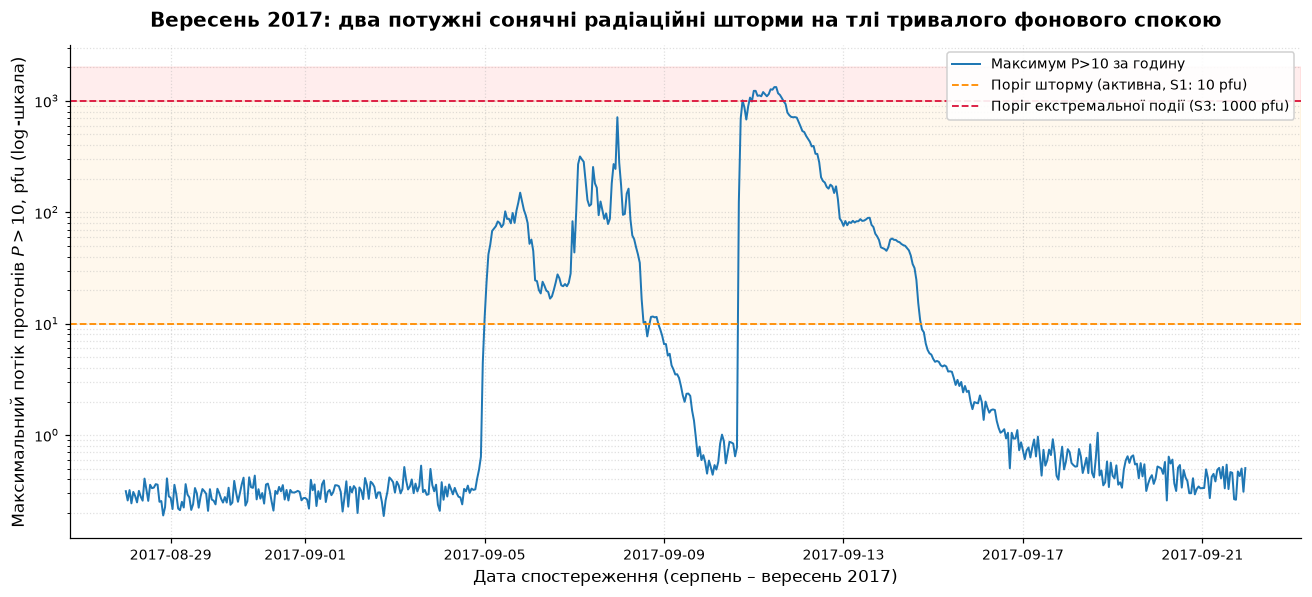

In [ ]:
# ВАШ КОД
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5.5))

# 1. Основна крива
plt.plot(M['ts'], M['P>10_max'], color='#1f77b4', linewidth=1.3, label='Максимум P>10 за годину')

# 2. Логарифмічна шкала
plt.yscale('log')

# 3. Референтні пороги за шкалою NOAA Space Weather Scales
plt.axhline(10, color='darkorange', linestyle='--', linewidth=1.2, label='Поріг шторму (активна, S1: 10 pfu)')
plt.axhline(1000, color='crimson', linestyle='--', linewidth=1.2, label='Поріг екстремальної події (S3: 1000 pfu)')

# Тіньове виділення зон для контексту
plt.axhspan(10, 1000, color='orange', alpha=0.07)
plt.axhspan(1000, M['P>10_max'].max() * 1.5, color='red', alpha=0.07)

# 4. Оформлення: заголовок-висновок та осі з одиницями
plt.title('Вересень 2017: два потужні сонячні радіаційні шторми на тлі тривалого фонового спокою', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Дата спостереження (серпень – вересень 2017)', fontsize=11)
plt.ylabel(r'Максимальний потік протонів $P>10$, $\mathrm{pfu}$ ($\log$-шкала)', fontsize=11)

plt.grid(True, which='both', linestyle=':', alpha=0.4)
plt.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()

**Відповідь 6.2:** *(чому ви побудували графік саме так)*

Обрано повний часовий діапазон, щоб не приховувати шторми маніпулятивним обрізанням вибірки, логарифмічну шкалу — щоб одночасно бачити фонові коливання й піки на кілька порядків вище, та порогові лінії — щоб надати даним зрозумілий контекст рівнів небезпеки.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** Увесь період підвищеної радіаційної активності сконцентрований лише у двох ізольованих часових подіях (5–9 вересня та 10–14 вересня), під час яких потік $P>10$ стрімко зростав на 3–4 порядки з піком понад $1000\text{ pfu}$ на тлі стабільного фонового рівня нижче $1\text{ pfu}$.

**Спостереження 2:** Попри відсутність загальної лінійної залежності між швидкістю сонячного вітру та потоком протонів, група «активних» годин демонструє виражені викиди швидкості вітру аж до 800 км/с, тоді як у групі «тиха» абсолютна більшість спостережень не перевищує 600 км/с.

**Спостереження 3:** Понад дві третини часу (68.5%, або 411 годин) сонячна активність залишалася тихою, тоді як стан високої небезпеки («дуже активна») фіксувався вкрай рідко — лише 18 годин (3.0% усього періоду).


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [ ]:
# ВАШ КОД
# Маска годин, які належать до групи 'активна'
is_active = M['група'] == 'активна'

# Визначення ідентифікаторів неперервних блоків (run-length encoding)
blocks = (~is_active).cumsum()

# Підрахунок тривалості кожної неперервної серії активних годин
active_streaks = is_active.groupby(blocks).sum()

# Знаходження максимальної неперервної тривалості
max_streak = int(active_streaks.max())
print(f"Найдовша неперервна серія активних годин: {max_streak} годин")

Найдовша неперервна серія активних годин: 87 годин


**Відповідь 7.2:** Найдовша неперервна серія активних годин: 87 годин

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [ ]:
ІНСТРУМЕНТИ_ШІ = 'Gemini, claude'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'код, перевірено',
    'етап 3, паспорт даних і дивні значення':     'код, перевірено',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'текст, перероблено',
    'етапи 6–7, порівняння графіків і спостереження': 'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = (
    'Перевірено вигляд таблиць після мерджу, звірено з реальними даними'
    'Діаграми спрощені до мінімально необхідного для виконання завданя'
    'Виправлено помилки при об`єднанні таблиць'
    'для потоку P>50 з візуальним відображенням на гістограмі; перевірено розподіл годин за категоріями'
    'Перевірено та досліджено усі формули, та специфічні функції побудови графіків'
    'Усі підсумкові текстові висновки скорочено до строго одного змістовного речення з видаленням зайвих слів.'
)

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [ ]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Бісюк Роман Васильович
інструменти:                                   Gemini, claude
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    код, перевірено
етап 3, паспорт даних і дивні значення:        код, перевірено
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                текст, перероблено
етапи 6–7, порівняння графіків і спостереження: код, перевірено
------------------------------------------------------------------------------
перевірено автором:
Перевірено вигляд таблиць після мерджу, звірено з реальними данимиДіаграми спрощені до мінімально необхідного для виконання завданяВиправлено помилки при об`єднанні таблицьдля потоку P>50 з візуальним відображенням на гістограмі; перевірено розподіл годин за катег

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [ ]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (600, 21)


In [ ]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
